# Kredi Kartı Dolandırıcılık Tespiti

In [ ]:
# !pip install imblearn

In [ ]:
# Linear Algebra
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import confusion_matrix

# Imbalanced Classes
import imblearn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# TensorFlow Keras
import keras
from keras import models
from keras import layers
from keras.callbacks import EarlyStopping
from keras import regularizers
from keras.optimizers import Adam
from keras.optimizers.schedules import ExponentialDecay


Önceki egzersizler, bir sinir ağının tüm farklı bölümlerini yakından incelemenizi sağladı:
* sıralı Yoğun Sinir Ağının mimarisi,
* derleme yöntemi
* eğitim.

Şimdi **çok fazla veriye sahip** gerçek bir veri seti üzerinde çalışalım!

**Veri seti: `Kredi Kartı İşlemleri`**

Bu açık meydan okuma için, `kredi kartı işlemlerinden çıkarılan verilerle` çalışacaksınız.

Bu `hassas veri` olduğu için, toplamda 31 sütunun yalnızca 3'ü biliniyor: geri kalanlar `anonimleştirmek` için dönüştürülmüş (aslında, bunlar `başlangıç verilerinin PCA projeksiyonları`).

Bilinen 3 sütun:

* `TIME`: işlem ile veri setindeki ilk işlem arasında geçen süre
* `AMOUNT`: işlem tutarı
* `CLASS` (hedefimiz): 
    * `0 : geçerli işlem` 
    * `1 : dolandırıcılık işlemi`

❓ **Soru** ❓ Veri setini indirerek başlayın:
* Kaggle web sitesinden [buradan](https://www.kaggle.com/mlg-ulb/creditcardfraud) 
* veya bizim [URL'mizden](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/creditcard.csv) 

`X` ve `y` oluşturmak için veriyi yükleyin

In [ ]:
# Veriyi yükle
df = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/creditcard.csv")

In [ ]:
# Veriyi seç
X = df.drop(columns=['Class'], axis=1).values
y = df['Class'].values

## 1. Sınıfları yeniden dengeleme

In [ ]:
# Sınıf dengesini kontrol edelim
pd.Series(y).value_counts(normalize=True)

0    0.998273
1    0.001727
Name: proportion, dtype: float64

☝️ Bu `dolandırıcılık tespit` meydan okumasında, **sınıflar son derece dengesiz**:
* Normal işlemlerin %99.8'i
* Dolandırıcılık işlemlerinin %0.2'si

**Ciddi yeniden dengeleme stratejileri uygulamadıkça dolandırıcılık vakalarını tespit edemeyeceğiz!**

❓ **Soru** ❓
1. **Öncelikle**, veri setinizden üç ayrı bölünme `Eğitim/Doğrulama/Test` oluşturun. Modelinizi değerlendirdiğinizde, veri sızıntısı olmadan gerçek koşullarda yapılması için doğrulama ve test setlerini **dengesiz** tutmak son derece önemlidir. Test setinizi bu notebook'un en son hücresine saklayın!

&nbsp;
2. **İkincisi**, eğitim setinizi (ve yalnızca bunu) yeniden dengeleyin. Birçok seçeneğiniz var:

- Düz Numpy fonksiyonlarını kullanarak azınlık sınıfını rastgele fazla örnekleme yapın (satırları çoğalttığınız ve dolayısıyla veri sızıntısı oluşturduğunuz için en iyi seçenek değil)
- Veya mevcut veri noktalarını ağırlıklandırarak yeni veri noktaları oluşturmak için <a href="https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/">**`Sentetik Azınlık Fazla Örnekleme Tekniği - SMOTE`**</a> kullanın
- Ayrıca, çoğunluk sınıfını biraz alt örnekleme yapmak için <a href="https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/">**`RandomUnderSampler`**</a> da deneyebilirsiniz

In [ ]:
# KODUNUZ BURAYA

In [ ]:
# Gerçek test setini korumak için herhangi bir yeniden örnekleme öncesi eğitim test bölünmesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3)

In [ ]:
print(f"X_train.shape = {X_train.shape}")
print(f"y_train.shape = {y_train.shape}")
print(f"X_val.shape = {X_val.shape}")
print(f"y_val.shape = {y_val.shape}")
print(f"X_test.shape = {X_test.shape}")
print(f"y_test.shape = {y_test.shape}")

X_train.shape = (139554, 30)
y_train.shape = (139554,)
X_val.shape = (59810, 30)
y_val.shape = (59810,)
X_test.shape = (85443, 30)
y_test.shape = (85443,)


In [ ]:
# Her bölünmede kaç "dolandırıcılık" örneği var?
print(np.sum(y_train[y_train == 1]))
print(np.sum(y_val[y_val == 1]))
print(np.sum(y_test[y_test == 1]))

print("-"*100)

print(f"Eğitim setinde {pd.Series(y_train).value_counts()[1]} dolandırıcılık işlemi var")
print(f"Doğrulama setinde {pd.Series(y_val).value_counts()[1]} dolandırıcılık işlemi var")
print(f"Test setinde {pd.Series(y_test).value_counts()[1]} dolandırıcılık işlemi var")

240
117
135
----------------------------------------------------------------------------------------------------
There are 240 fraudulent transactions in the train set
There are 117 fraudulent transactions in the val set
There are 135 fraudulent transactions in the test set


In [ ]:
# Örnekleme stratejileri
over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.33)

In [ ]:
from sklearn import set_config;  set_config(display='diagram')

# İki stratejiyi ardışık bağlama
steps =  [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)
pipeline

Pipeline(steps=[('o', SMOTE(sampling_strategy=0.1)),
                ('u', RandomUnderSampler(sampling_strategy=0.33))])

In [ ]:
# Veri setini yeniden dengele
X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train, y_train)

print(f"X_train_resampled.shape = {X_train_resampled.shape}")
print(f"y_train_resampled.shape = {y_train_resampled.shape}")

X_train_resampled.shape = (56146, 30)
y_train_resampled.shape = (56146,)


In [ ]:
# Yeniden örneklenmiş veriyi emin olmak için yeniden karıştır
stacked_resampled_data = np.hstack([X_train_resampled, y_train_resampled.reshape(-1,1)])
np.random.shuffle(stacked_resampled_data)

X_train_resampled = stacked_resampled_data[:,:30]
y_train_resampled = stacked_resampled_data[:,-1]

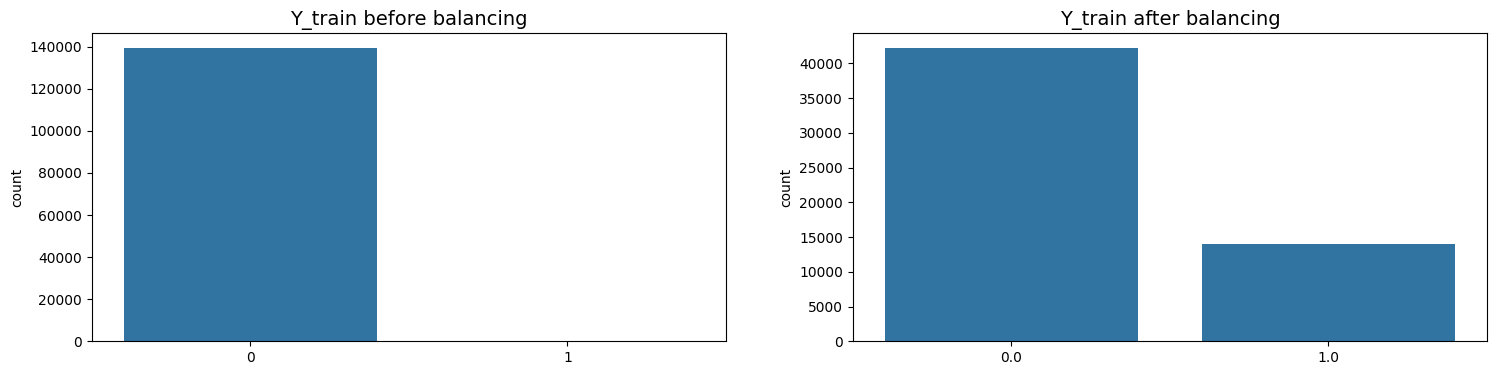

In [ ]:
# çizim
warnings.filterwarnings('ignore')
fig, ax = plt.subplots(1, 2, figsize=(18,4))

''' Sınıfları dengelemeden önce'''

sns.countplot(x=y_train, ax=ax[0])
ax[0].set_title('Y_train dengelemeden önce', fontsize=14)

''' Sınıfları dengeledikten sonra'''

sns.countplot(x=y_train_resampled, ax=ax[1])
ax[1].set_title('Y_train dengeledikten sonra', fontsize=14);

In [ ]:
print(X_train_resampled.shape)
print(X_val.shape)

(56146, 30)
(59810, 30)


## 2. Sinir Ağı iterasyonları

Sınıflarınızı yeniden dengelediğinizde göre, test puanınızı optimize etmek için bir sinir ağı eğitmeye çalışın. Aşağıdaki ipuçlarını kullanmaktan çekinmeyin:

- Girişlerinizi normalleştirin!
    - Tercihen modelinizin içinde ön işlemenizi modeliniz içinde "ardışık bağlamak" için bir [`Normalization`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization) katmanı kullanın.
    - Veya modelinizin dışında sklearn'in [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)'ını kullanın, `X_train` ve `X_val` ve `X_test`'e uygulayın.
- Modelinizin aşırı öğrenmesini sağlayın, ardından şunları kullanarak düzenleyin:
    - Erken Durdurma kriterleri
    - [`Dropout`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) katmanları
    - veya [`regularizers`](https://www.tensorflow.org/api_docs/python/tf/keras/regularizers) katmanları
- 🚨 İzlemek istediğiniz metrikler ve kullanmak istediğiniz kayıp fonksiyonu hakkında dikkatli düşünün!

In [ ]:
# KODUNUZ BURAYA

In [ ]:
metrics = [
    keras.metrics.Recall(name='recall'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.AUC(name='prc', curve='PR'),  # precision-recall curve
]

In [ ]:
from tensorflow.keras.layers import Normalization
from tensorflow.keras.metrics import Recall, Precision

def init_model():
    input_shape = X_train_resampled.shape[1:]
    normalizer = Normalization()
    normalizer.adapt(X_train_resampled)

    model = models.Sequential()
    model.add(normalizer)
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(16, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(8, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))

    # Model compilation
    optimizer = Adam(learning_rate=0.0001)
    model.compile(loss='binary_crossentropy',
                  optimizer=optimizer,
                  metrics=metrics)
    return model

### Düzenlenmiş model

In [ ]:
model = init_model()
#model.summary()

In [ ]:
es = EarlyStopping(
    patience=10,
    monitor='val_recall', # Dolandırıcılık işlemlerini gerçekten tespit etmek istiyoruz!
    restore_best_weights=True)

history = model.fit(X_train_resampled, y_train_resampled,
                    validation_data=(X_val, y_val),
                    epochs=100,
                    batch_size=64, # Dolandırıcılık işlemlerini içerme şansı elde etmek için yeterince büyük
                    callbacks=[es], shuffle=True)

Epoch 1/100
878/878 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8879 - prc: 0.5814 - precision: 0.2562 - recall: 0.9424 - val_loss: 0.6728 - val_prc: 0.3870 - val_precision: 0.0138 - val_recall: 0.8205
Epoch 2/100
878/878 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5938 - prc: 0.8545 - precision: 0.5271 - recall: 0.8552 - val_loss: 0.6204 - val_prc: 0.5446 - val_precision: 0.1115 - val_recall: 0.7607
Epoch 3/100
878/878 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5202 - prc: 0.9120 - precision: 0.8690 - recall: 0.8409 - val_loss: 0.5165 - val_prc: 0.6349 - val_precision: 0.3580 - val_recall: 0.7863
Epoch 4/100
878/878 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4097 - prc: 0.9202 - precision: 0.9550 - recall: 0.8422 - val_loss: 0.2215 - val_prc: 0.6761 - val_precision: 0.6414 - val_recall: 0.7949
Epoch 5/100
878/878 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2685 - prc: 0.9322 - precision: 0.9780 - recall: 0.8588 - val_loss: 0.0997 - val_prc: 0.6821 - val_precision: 0.6078 - val_recall: 0.

In [ ]:
def plot_loss_precision_recall_curve(history):

    fig, ax =plt.subplots(1, 3, figsize=(20,5))

    # --- LOSS

    ax[0].plot(history.history['loss'])
    ax[0].plot(history.history['val_loss'])
    ax[0].set_title('Model loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend(['Train', 'Val'], loc='upper right')
    ax[0].grid(axis="x", linewidth=0.5)
    ax[0].grid(axis="y", linewidth=0.5)

    # --- RECALL

    ax[1].plot(history.history['recall'])
    ax[1].plot(history.history['val_recall'])
    ax[1].set_title('Model recall', fontsize=18)
    ax[1].set_xlabel('Epoch', fontsize=14)
    ax[1].set_ylabel('Recall', fontsize=14)
    ax[1].legend(['Train', 'Val'], loc='lower right')
    ax[1].grid(axis="x", linewidth=0.5)
    ax[1].grid(axis="y", linewidth=0.5)


    # --- PRECISION


    ax[2].plot(history.history['precision'])
    ax[2].plot(history.history['val_precision'])
    ax[2].set_title('Model precision', fontsize=18)
    ax[2].set_xlabel('Epoch', fontsize=14)
    ax[2].set_ylabel('Precision', fontsize=14)
    ax[2].legend(['Train', 'Val'], loc='lower right')
    ax[2].grid(axis="x", linewidth=0.5)
    ax[2].grid(axis="y", linewidth=0.5)

    plt.show()

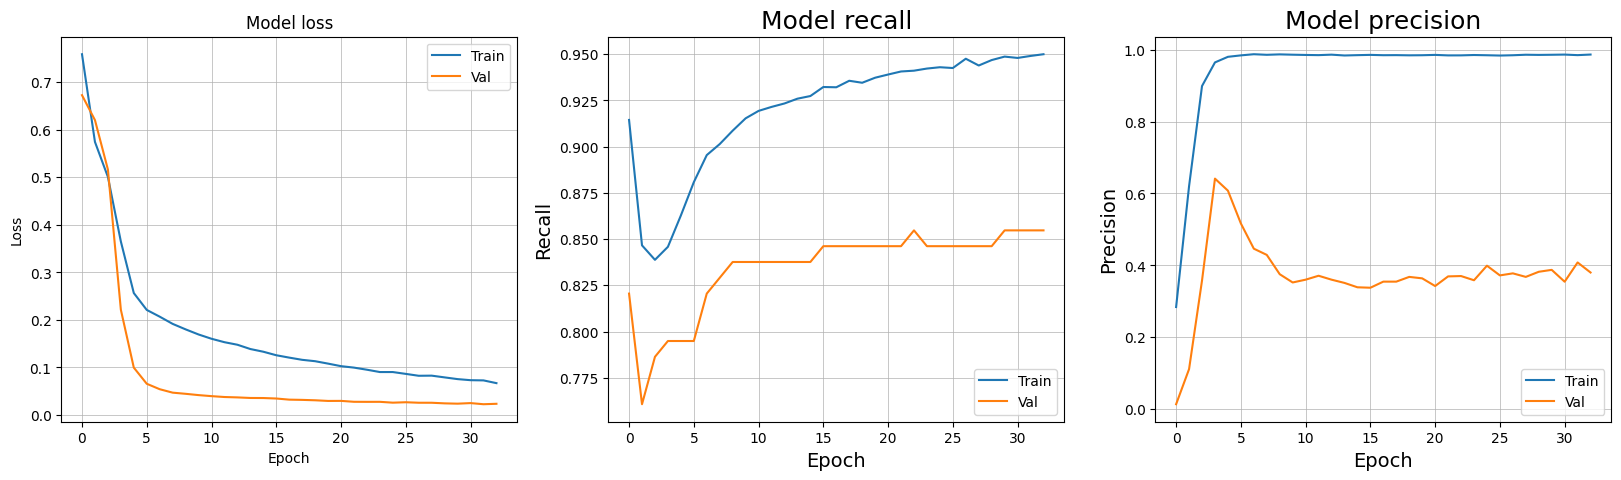

In [ ]:
plot_loss_precision_recall_curve(history)

Hatırlama (recall) üzerinde optimize ederek, kesinliği (precision) "feda ediyoruz"!

🎯 Bir banka müdürü olarak, tüm dolandırıcılıkların tespit edilmesini istiyorsunuz.

✅ Yanlış Pozitifler, Yanlış Alarmlar tahmin etmek sorun değil: `Güvenlik her şeyden önemli...`

## 3. Modelinizi görünmeyen Test setinde puanlayın

❓ **Soru** ❓: Test setindeki karışıklık matrisinizi ve sınıflandırma raporunuzu hesaplayın

In [ ]:
model.evaluate(X_test, y_test, verbose=0, return_dict=True)

{'loss': 0.026467949151992798,
 'prc': 0.7307383418083191,
 'precision': 0.3444444537162781,
 'recall': 0.9185185432434082}

In [ ]:
y_pred_proba = model.predict(X_test)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 2s 672us/step


In [ ]:
threshold = 0.50 # 50%

y_pred_binary = np.where(y_pred_proba > threshold, 1, 0 )

### Karışıklık Matrisi

In [ ]:
# Karışıklık Matrisi
cm = confusion_matrix(y_test, y_pred_binary)
cm

array([[85072,   236],
       [   11,   124]])

Text(0.5, 25.722222222222214, 'Predicted label')

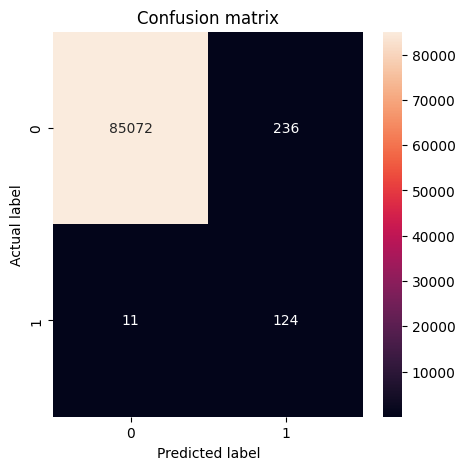

In [ ]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title('Karışıklık matrisi')
plt.ylabel('Gerçek etiket')
plt.xlabel('Tahmin edilen etiket')

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_binary))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85308
           1       0.34      0.92      0.50       135

    accuracy                           1.00     85443
   macro avg       0.67      0.96      0.75     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
from sklearn.metrics import precision_recall_curve

def plot_prc(name, labels, predictions, **kwargs):
    precision, recall, _ = precision_recall_curve(labels, predictions)
    plt.plot(recall, precision, label=name, linewidth=2, **kwargs)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid(True)
    ax = plt.gca()
    ax.set_aspect('equal')

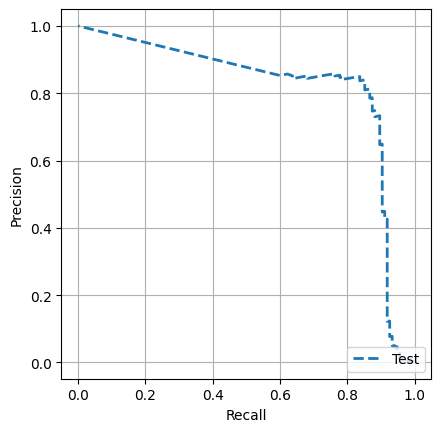

In [ ]:
plot_prc("Test", y_test, y_pred_proba, linestyle='--')
plt.legend(loc='lower right')

### 🧪 Puanınızı test edin

Orijinal dengesiz veri setinin temsilci örneklemi (`X_test`, `y_test`) üzerindeki gerçek test performansınızı aşağıdaki `precision` ve `recall` değişkenlerine kaydedin.

In [ ]:
precision =  0.67
recall = 0.75001

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('solution',
    precision=precision,
    recall=recall,
    fraud_number=len(y_test[y_test == 1]),
    non_fraud_number=len(y_test[y_test == 0]),
)

result.write()
print(result.check())

## 🏁 İsteğe bağlı: Bu meydan okuma için Google'ın çözümünü okuyun
Bu oturum için tüm meydan okumaları bitirdiğiniz için tebrikler!

Sonuç olarak, Google'ın kendi çözümünü doğrudan [Colab'da buradan](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/structured_data/imbalanced_data.ipynb) okumak için zaman ayırın.

İlginç teknikleri ve en iyi uygulamaları keşfedeceksiniz